# Swin Transformer

## Objective

This notebook evaluates a Swin Transformer architecture on the same fixed
brain tumor MRI classification benchmark used for the EfficientNetV2 baseline.

The experiment reuses:

- the same 11,300 MRI images;
- the same 357 reconstructed leakage-aware groups;
- the same frozen train, validation, and test partitions;
- the same 10-class pathology target;
- the same evaluation protocol.

The objective is to determine whether a hierarchical vision transformer can
generalize better than the EfficientNetV2B0 CNN baseline on independent
reconstructed MRI case groups.

The test partition will remain untouched during model development and will be
used only for final evaluation.

## 1. Setup and experiment configuration

In [3]:
!nvidia-smi

Sun Sep 13 18:59:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install -q timm

In [5]:
import torch
import timm

print("PyTorch version:", torch.__version__)
print("timm version:", timm.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
timm version: 1.0.29
CUDA available: True
GPU: Tesla T4


In [6]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import torch

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [7]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
PROJECT_ROOT = Path("/content/brain-tumor-mri")

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "classification_manifest.csv"
)

DRIVE_MANIFEST = Path(
    "/content/drive/MyDrive/classification_manifest.csv"
)

DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/brain-tumor-mri/models"
)

DRIVE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [9]:
import shutil

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw directory:", RAW_DIR)
print("Processed directory:", PROCESSED_DIR)
print("Drive manifest exists:", DRIVE_MANIFEST.exists())

Raw directory: /content/brain-tumor-mri/data/raw
Processed directory: /content/brain-tumor-mri/data/processed
Drive manifest exists: True


In [10]:
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get(
    "KAGGLE_API_TOKEN"
)

print("✓ Kaggle token loaded.")

✓ Kaggle token loaded.


In [11]:
!kaggle datasets download \
    -d fernando2rad/brain-tumor-mri-images-30-classes \
    -p /content/brain-tumor-mri/data/raw \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-30-classes
License(s): apache-2.0
100% 478M/478M [00:25<00:00, 19.9MB/s]



In [12]:
image_files = list(RAW_DIR.rglob("*.jpg"))

print("Images found:", len(image_files))
print(
    "DATA.json exists:",
    (RAW_DIR / "DATA.json").exists()
)

Images found: 11300
DATA.json exists: True


In [13]:
shutil.copy2(
    DRIVE_MANIFEST,
    MANIFEST_PATH
)

manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", manifest.shape)
print()
print(manifest["split"].value_counts())

Manifest shape: (11300, 12)

split
train         7928
validation    1699
test          1673
Name: count, dtype: int64


In [14]:
train_df = manifest[manifest["split"] == "train"].copy()
val_df = manifest[manifest["split"] == "validation"].copy()
test_df = manifest[manifest["split"] == "test"].copy()

assert len(train_df) == 7928
assert len(val_df) == 1699
assert len(test_df) == 1673

assert set(train_df["split_group"]).isdisjoint(val_df["split_group"])
assert set(train_df["split_group"]).isdisjoint(test_df["split_group"])
assert set(val_df["split_group"]).isdisjoint(test_df["split_group"])

print("✓ Frozen manifest loaded successfully.")
print("✓ Expected split sizes recovered.")
print("✓ No split_group crosses partitions.")

✓ Frozen manifest loaded successfully.
✓ Expected split sizes recovered.
✓ No split_group crosses partitions.


In [15]:
for subset in [train_df, val_df, test_df]:
    subset["image_path"] = subset["resolved_relative_path"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )

assert train_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert val_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert test_df["image_path"].apply(lambda p: Path(p).exists()).all()

print("✓ All image paths exist.")

✓ All image paths exist.


In [16]:
CLASS_NAMES = sorted(train_df["pathology"].unique())

class_to_index = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

index_to_class = {
    idx: class_name
    for class_name, idx in class_to_index.items()
}

for subset in [train_df, val_df, test_df]:
    subset["label"] = subset["pathology"].map(class_to_index)

NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", NUM_CLASSES)
print(CLASS_NAMES)

Classes: 10
['Astrocytoma', 'Ependymoma', 'Glioma', 'Hemangiopericytoma', 'Meningioma', 'Neurocytoma', 'Normal', 'Oligodendroglioma', 'Other', 'Schwannoma']


In [17]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

In [18]:
SWIN_MODEL_NAME = "swin_tiny_patch4_window7_224.ms_in1k"

swin_reference = timm.create_model(
    SWIN_MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

data_config = resolve_data_config(
    swin_reference.pretrained_cfg
)

print(data_config)

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.9, 'crop_mode': 'center'}


In [19]:
train_transform = create_transform(
    **data_config,
    is_training=True
)

eval_transform = create_transform(
    **data_config,
    is_training=False
)

print("Train transform:")
print(train_transform)

print("\nEvaluation transform:")
print(eval_transform)

Train transform:
Compose(
    RandomResizedCropAndInterpolation(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bicubic)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.6, 1.4), hue=None)
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)

Evaluation transform:
Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [20]:
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [21]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7928
Validation: 1699
Test: 1673


In [22]:
print(data_config)
print(train_transform)

{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.9, 'crop_mode': 'center'}
Compose(
    RandomResizedCropAndInterpolation(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bicubic)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.6, 1.4), hue=None)
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [23]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = data_config["mean"]
IMAGENET_STD = data_config["std"]

train_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomAffine(
        degrees=10.8,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=InterpolationMode.BICUBIC,
        fill=0
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Train transform:")
print(train_transform)

print("\nEvaluation transform:")
print(eval_transform)

Train transform:
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    RandomAffine(degrees=[-10.8, 10.8], translate=(0.03, 0.03), scale=(0.95, 1.05), interpolation=bicubic)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Evaluation transform:
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [24]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7928
Validation: 1699
Test: 1673


In [25]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 248
Validation batches: 54
Test batches: 53


In [26]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print(
    "Label range:",
    labels.min().item(),
    labels.max().item()
)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Label range: 0 9


In [27]:

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(image):
    image = image.cpu() * std + mean
    return torch.clamp(image, 0, 1)

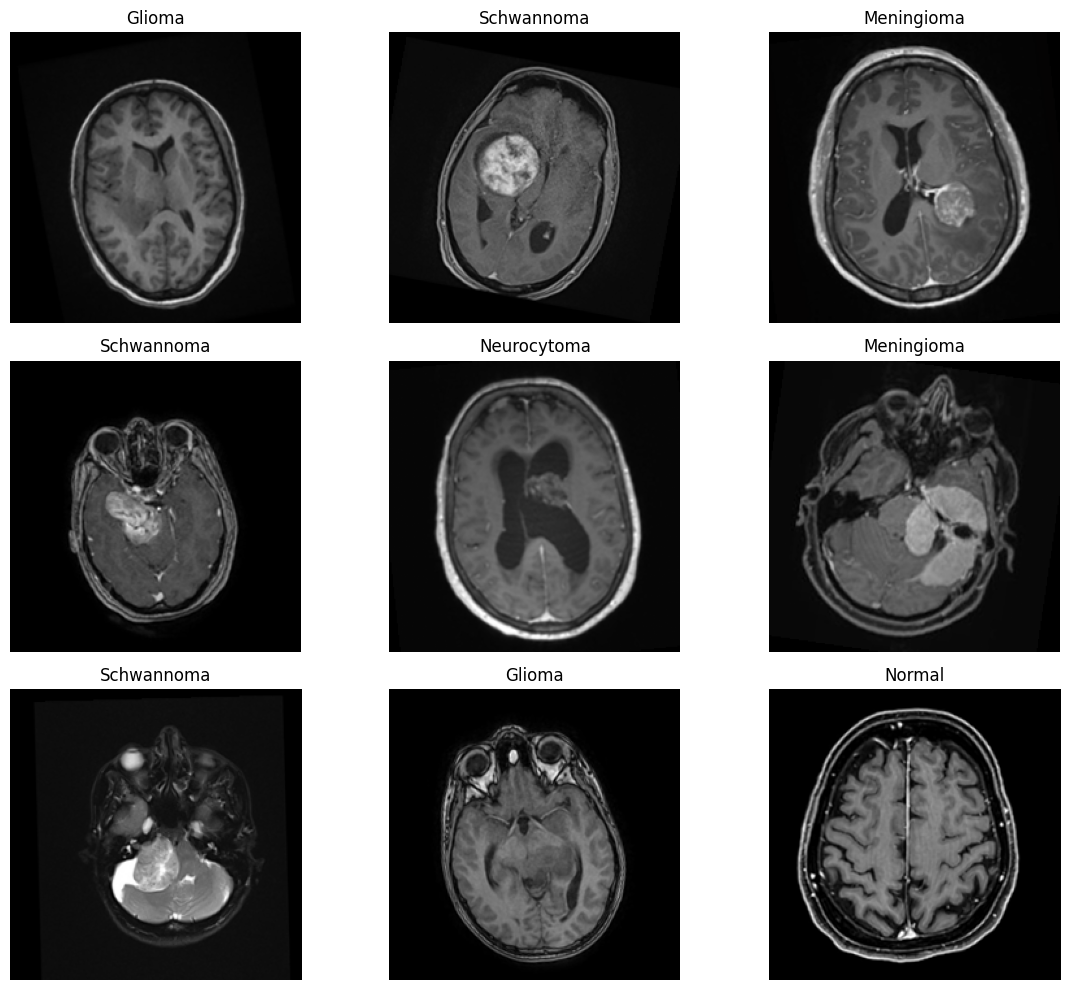

In [29]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 10))

for i in range(9):
    image = denormalize(images[i])
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)

    plt.title(
        index_to_class[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [31]:
SWIN_MODEL_NAME = "swin_tiny_patch4_window7_224.ms_in1k"

model = timm.create_model(
    SWIN_MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

print("Model:", SWIN_MODEL_NAME)
print("Number of classes:", model.num_classes)
print("Classifier:")
print(model.head)

Model: swin_tiny_patch4_window7_224.ms_in1k
Number of classes: 10
Classifier:
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=10, bias=True)
  (flatten): Identity()
)


In [32]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 27,527,044
Trainable parameters: 27,527,044


In [33]:
for name, module in model.named_children():
    print(
        f"{name:15s} -> "
        f"{module.__class__.__name__}"
    )

patch_embed     -> PatchEmbed
layers          -> Sequential
norm            -> LayerNorm
head            -> ClassifierHead


### Frozen-backbone transfer-learning baseline

The first Swin Transformer experiment follows the same transfer-learning
principle used for the EfficientNetV2B0 reference baseline.

The ImageNet-pretrained Swin backbone is initially frozen, while only the
newly initialized 10-class classification head is trained.

This provides a controlled architecture comparison before evaluating whether
selective fine-tuning of the transformer backbone improves generalization.

In [34]:
# Freeze the complete pretrained backbone
for parameter in model.parameters():
    parameter.requires_grad = False

# Re-enable the classification head
for parameter in model.head.parameters():
    parameter.requires_grad = True

In [35]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 27,527,044
Trainable parameters: 7,690


In [36]:
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name, parameter.shape)

head.fc.weight torch.Size([10, 768])
head.fc.bias torch.Size([10])


In [37]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

### Training configuration

The frozen Swin-Tiny backbone is trained using AdamW optimization.

Only the newly initialized classification head is optimized during this
baseline experiment. Validation loss is used for model selection, while
early stopping limits unnecessary training once generalization stops
improving.

In [38]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Loss: CrossEntropyLoss()
Optimizer: AdamW
Initial learning rate: 0.001


In [39]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients from previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [40]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [41]:
train_loss, train_accuracy = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    DEVICE
)

val_loss, val_accuracy = evaluate(
    model,
    val_loader,
    criterion,
    DEVICE
)

print(f"Train loss: {train_loss:.4f}")
print(f"Train accuracy: {train_accuracy:.4f}")

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Train loss: 1.6297
Train accuracy: 0.4542
Validation loss: 2.2315
Validation accuracy: 0.2313


### Frozen-backbone baseline training

The Swin-Tiny backbone remains frozen during this experiment, and only
the classification head is optimized.

The best model is selected according to validation loss. Learning-rate
reduction and early stopping are used to limit overfitting and unnecessary
training.

In [42]:
from pathlib import Path
import copy

SWIN_BASELINE_PATH = (
    DRIVE_MODEL_DIR
    / "swin_tiny_224_baseline.pt"
)

MAX_EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

In [43]:
# Rebuild a fresh Swin-Tiny model after the smoke test
model = timm.create_model(
    SWIN_MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

# Freeze pretrained backbone
for parameter in model.parameters():
    parameter.requires_grad = False

# Train only the classification head
for parameter in model.head.parameters():
    parameter.requires_grad = True

In [44]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [45]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Trainable parameters: 7,690
Initial learning rate: 0.001


In [46]:
for epoch in range(MAX_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{MAX_EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.4f}"
    )

    print(
        f"Learning rate: {current_lr:.6f}"
    )

    # Scheduler monitors validation loss
    scheduler.step(val_loss)

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "val_accuracy": val_accuracy,
                "class_names": CLASS_NAMES,
                "model_name": SWIN_MODEL_NAME,
            },
            SWIN_BASELINE_PATH
        )

        print(
            f"✓ Best model saved "
            f"(val_loss={best_val_loss:.4f})"
        )

    else:
        epochs_without_improvement += 1

        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch: {best_epoch}."
        )
        break


Epoch 1/30
Train loss: 1.6406 | Train accuracy: 0.4376
Val loss: 2.1478 | Val accuracy: 0.2590
Learning rate: 0.001000
✓ Best model saved (val_loss=2.1478)

Epoch 2/30
Train loss: 1.3027 | Train accuracy: 0.5796
Val loss: 2.2295 | Val accuracy: 0.2731
Learning rate: 0.001000
No improvement for 1 epoch(s).

Epoch 3/30
Train loss: 1.1685 | Train accuracy: 0.6258
Val loss: 2.3520 | Val accuracy: 0.2649
Learning rate: 0.001000
No improvement for 2 epoch(s).

Epoch 4/30
Train loss: 1.0816 | Train accuracy: 0.6511
Val loss: 2.3701 | Val accuracy: 0.2643
Learning rate: 0.001000
No improvement for 3 epoch(s).

Epoch 5/30
Train loss: 1.0217 | Train accuracy: 0.6787
Val loss: 2.3758 | Val accuracy: 0.2749
Learning rate: 0.000500
No improvement for 4 epoch(s).

Epoch 6/30
Train loss: 0.9994 | Train accuracy: 0.6829
Val loss: 2.4025 | Val accuracy: 0.2590
Learning rate: 0.000500
No improvement for 5 epoch(s).
Early stopping at epoch 6. Best epoch: 1.


In [47]:
print("\nTraining complete.")
print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")


Training complete.
Best epoch: 1
Best validation loss: 2.1478


### Frozen Swin-Tiny baseline — outcome

The frozen-backbone Swin-Tiny baseline also showed rapid overfitting.

The best validation loss was obtained at epoch 1:

- validation accuracy: 25.9%
- validation loss: 2.1478

Training accuracy subsequently increased from 43.8% to 68.3%, while validation
accuracy remained around 26–27% and validation loss progressively increased.

The frozen Swin-Tiny baseline therefore underperformed the frozen
EfficientNetV2B0 reference baseline, which achieved approximately 30.1%
validation accuracy with a validation loss of 2.0523.

This suggests that directly transferring fixed ImageNet representations from a
hierarchical vision transformer is not sufficient for this MRI classification
task.

## Selective Swin fine-tuning

The frozen Swin-Tiny baseline did not outperform the CNN reference.

A second experiment therefore fine-tunes only the final hierarchical Swin
stage, together with the final normalization and classification head.

Earlier transformer stages remain frozen to preserve generic pretrained
features while allowing higher-level representations to adapt to brain MRI
data.

In [48]:
checkpoint = torch.load(
    SWIN_BASELINE_PATH,
    map_location=DEVICE
)

model = timm.create_model(
    SWIN_MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print(
    "Loaded frozen baseline from epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

Loaded frozen baseline from epoch: 1
Validation loss: 2.1478237110842953


In [52]:
# Freeze the entire model
for parameter in model.parameters():
    parameter.requires_grad = False

# Fine-tune only the final transformer block
for parameter in model.layers[-1].blocks[-1].parameters():
    parameter.requires_grad = True

# Fine-tune final normalization
for parameter in model.norm.parameters():
    parameter.requires_grad = True

# Fine-tune classification head
for parameter in model.head.parameters():
    parameter.requires_grad = True

In [53]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,} / {total_params:,}"
)

print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

Trainable parameters: 7,101,154 / 27,527,044
Trainable percentage: 25.80%


In [54]:
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

layers.3.blocks.1.norm1.weight
layers.3.blocks.1.norm1.bias
layers.3.blocks.1.attn.relative_position_bias_table
layers.3.blocks.1.attn.qkv.weight
layers.3.blocks.1.attn.qkv.bias
layers.3.blocks.1.attn.proj.weight
layers.3.blocks.1.attn.proj.bias
layers.3.blocks.1.norm2.weight
layers.3.blocks.1.norm2.bias
layers.3.blocks.1.mlp.fc1.weight
layers.3.blocks.1.mlp.fc1.bias
layers.3.blocks.1.mlp.fc2.weight
layers.3.blocks.1.mlp.fc2.bias
norm.weight
norm.bias
head.fc.weight
head.fc.bias


In [55]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layers[-1].blocks[-1].parameters(),
            "lr": 1e-5,
        },
        {
            "params": model.norm.parameters(),
            "lr": 1e-5,
        },
        {
            "params": model.head.parameters(),
            "lr": 1e-4,
        },
    ],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

### Selective fine-tuning training

Only the final transformer block, final normalization layer, and classification
head are trainable in this experiment.

A lower learning rate is applied to the pretrained transformer parameters,
while the classification head uses a slightly higher learning rate.

Validation loss is used for checkpoint selection and early stopping.

In [56]:
SWIN_FINETUNED_PATH = (
    DRIVE_MODEL_DIR
    / "swin_tiny_224_finetuned.pt"
)

MAX_EPOCHS_FT = 20
PATIENCE_FT = 5

best_val_loss_ft = float("inf")
best_epoch_ft = 0
epochs_without_improvement_ft = 0

history_ft = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "backbone_lr": [],
    "head_lr": []
}

In [57]:
for epoch in range(MAX_EPOCHS_FT):
    print(f"\nEpoch {epoch + 1}/{MAX_EPOCHS_FT}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    backbone_lr = optimizer.param_groups[0]["lr"]
    head_lr = optimizer.param_groups[2]["lr"]

    history_ft["train_loss"].append(train_loss)
    history_ft["train_accuracy"].append(train_accuracy)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_accuracy"].append(val_accuracy)
    history_ft["backbone_lr"].append(backbone_lr)
    history_ft["head_lr"].append(head_lr)

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.4f}"
    )

    print(
        f"Backbone LR: {backbone_lr:.2e} | "
        f"Head LR: {head_lr:.2e}"
    )

    scheduler.step(val_loss)

    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        best_epoch_ft = epoch + 1
        epochs_without_improvement_ft = 0

        torch.save(
            {
                "epoch": best_epoch_ft,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss_ft,
                "val_accuracy": val_accuracy,
                "class_names": CLASS_NAMES,
                "model_name": SWIN_MODEL_NAME,
                "fine_tuning": "last_block_norm_head",
            },
            SWIN_FINETUNED_PATH
        )

        print(
            f"✓ Best fine-tuned model saved "
            f"(val_loss={best_val_loss_ft:.4f})"
        )

    else:
        epochs_without_improvement_ft += 1

        print(
            f"No improvement for "
            f"{epochs_without_improvement_ft} epoch(s)."
        )

    if epochs_without_improvement_ft >= PATIENCE_FT:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch: {best_epoch_ft}."
        )
        break


Epoch 1/20
Train loss: 1.2598 | Train accuracy: 0.5864
Val loss: 2.2721 | Val accuracy: 0.2590
Backbone LR: 1.00e-05 | Head LR: 1.00e-04
✓ Best fine-tuned model saved (val_loss=2.2721)

Epoch 2/20
Train loss: 1.1068 | Train accuracy: 0.6471
Val loss: 2.2930 | Val accuracy: 0.2649
Backbone LR: 1.00e-05 | Head LR: 1.00e-04
No improvement for 1 epoch(s).

Epoch 3/20
Train loss: 0.9842 | Train accuracy: 0.6915
Val loss: 2.3156 | Val accuracy: 0.2625
Backbone LR: 1.00e-05 | Head LR: 1.00e-04
No improvement for 2 epoch(s).

Epoch 4/20
Train loss: 0.8888 | Train accuracy: 0.7253
Val loss: 2.3663 | Val accuracy: 0.2649
Backbone LR: 1.00e-05 | Head LR: 1.00e-04
No improvement for 3 epoch(s).

Epoch 5/20
Train loss: 0.8075 | Train accuracy: 0.7539
Val loss: 2.3729 | Val accuracy: 0.2772
Backbone LR: 5.00e-06 | Head LR: 5.00e-05
No improvement for 4 epoch(s).

Epoch 6/20
Train loss: 0.7673 | Train accuracy: 0.7643
Val loss: 2.4105 | Val accuracy: 0.2566
Backbone LR: 5.00e-06 | Head LR: 5.00e-05


In [58]:
print("\nFine-tuning complete.")
print("Best epoch:", best_epoch_ft)
print(f"Best validation loss: {best_val_loss_ft:.4f}")


Fine-tuning complete.
Best epoch: 1
Best validation loss: 2.2721


### Selective Swin fine-tuning — outcome

Selective fine-tuning of the final Swin transformer block did not improve
validation performance.

The best fine-tuned checkpoint was obtained at epoch 1 with:

- validation accuracy: 25.9%
- validation loss: 2.2721

This is worse than the frozen Swin-Tiny baseline, which achieved a validation
loss of 2.1478 with the same validation accuracy.

Training accuracy increased rapidly to more than 76%, while validation
performance remained around 26–27%, indicating substantial overfitting.

Therefore, selectively fine-tuning the final transformer block, normalization
layer, and classification head does not improve generalization on the
independent reconstructed MRI case groups.

## Swin Transformer experiment summary

In [59]:

history_swin = pd.DataFrame(history)

history_swin

,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1.640593,0.437563,2.147824,0.258976,0.0010
1,1.302710,0.579591,2.229537,0.273102,0.0010
2,1.168503,0.625757,2.352048,0.264862,0.0010
3,1.081588,0.651110,2.370101,0.264273,0.0010
4,1.021730,0.678734,2.375752,0.274868,0.0005
5,0.999356,0.682896,2.402549,0.258976,0.0005


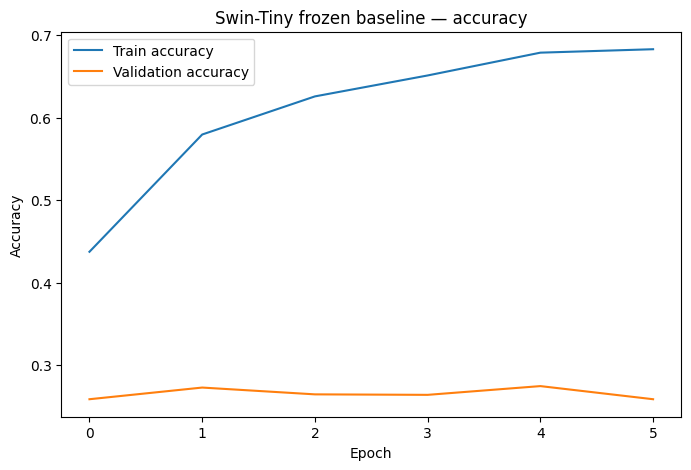

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_swin["train_accuracy"],
    label="Train accuracy"
)

plt.plot(
    history_swin["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Swin-Tiny frozen baseline — accuracy")
plt.legend()

plt.show()

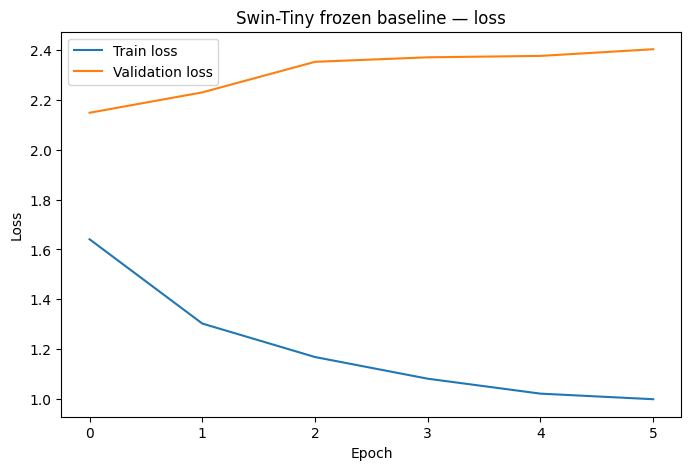

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_swin["train_loss"],
    label="Train loss"
)

plt.plot(
    history_swin["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin-Tiny frozen baseline — loss")
plt.legend()

plt.show()

In [62]:
history_swin_ft = pd.DataFrame(history_ft)

history_swin_ft

,train_loss,train_accuracy,val_loss,val_accuracy,backbone_lr,head_lr
0,1.259821,0.586403,2.272111,0.258976,0.000010,0.00010
1,1.106823,0.647074,2.292983,0.264862,0.000010,0.00010
2,0.984192,0.691473,2.315576,0.262507,0.000010,0.00010
3,0.888824,0.725277,2.366286,0.264862,0.000010,0.00010
4,0.807497,0.753910,2.372935,0.277222,0.000005,0.00005
5,0.767286,0.764253,2.410467,0.256622,0.000005,0.00005


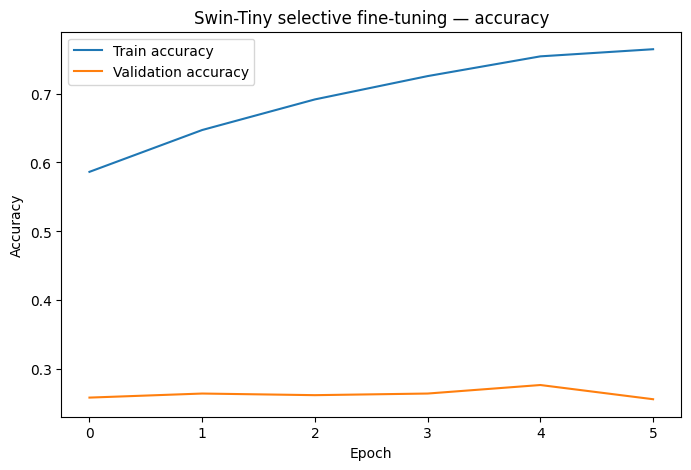

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_swin_ft["train_accuracy"],
    label="Train accuracy"
)

plt.plot(
    history_swin_ft["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Swin-Tiny selective fine-tuning — accuracy")
plt.legend()

plt.show()

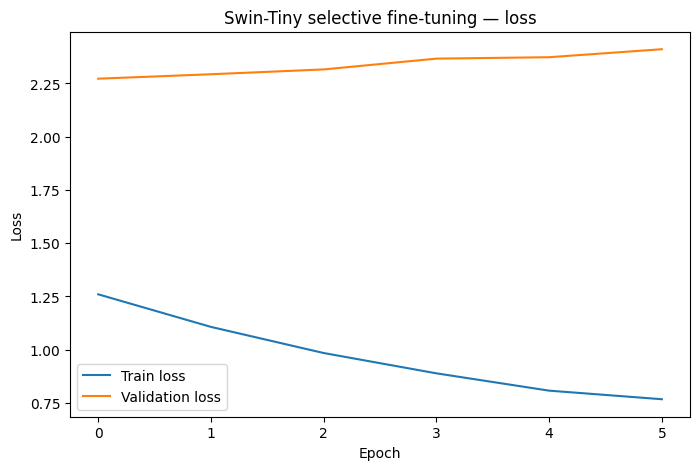

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_swin_ft["train_loss"],
    label="Train loss"
)

plt.plot(
    history_swin_ft["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin-Tiny selective fine-tuning — loss")
plt.legend()

plt.show()

In [66]:
comparison = pd.DataFrame([
    {
        "model": "EfficientNetV2B0",
        "input_size": "224×224",
        "strategy": "Frozen backbone",
        "selected_val_accuracy": 0.3014,
        "best_val_loss": 2.0523
    },
    {
        "model": "EfficientNetV2B0",
        "input_size": "224×224",
        "strategy": "Partial fine-tuning",
        "selected_val_accuracy": 0.2902,
        "best_val_loss": 2.1013
    },
    {
        "model": "EfficientNetV2B0",
        "input_size": "300×300",
        "strategy": "Frozen backbone",
        "selected_val_accuracy": 0.2448,
        "best_val_loss": 2.0763
    },
    {
        "model": "Swin-Tiny",
        "input_size": "224×224",
        "strategy": "Frozen backbone",
        "selected_val_accuracy": 0.2590,
        "best_val_loss": 2.1478
    },
    {
        "model": "Swin-Tiny",
        "input_size": "224×224",
        "strategy": "Selective fine-tuning",
        "selected_val_accuracy": 0.2590,
        "best_val_loss": 2.2721
    }
])

comparison

,model,input_size,strategy,selected_val_accuracy,best_val_loss
0,EfficientNetV2B0,224×224,Frozen backbone,0.3014,2.0523
1,EfficientNetV2B0,224×224,Partial fine-tuning,0.2902,2.1013
2,EfficientNetV2B0,300×300,Frozen backbone,0.2448,2.0763
3,Swin-Tiny,224×224,Frozen backbone,0.2590,2.1478
4,Swin-Tiny,224×224,Selective fine-tuning,0.2590,2.2721


### Final conclusions

Across all evaluated configurations, the 224×224 frozen EfficientNetV2B0
baseline remained the best-performing model on the validation partition.

Neither increasing EfficientNet input resolution nor partially fine-tuning its
backbone improved generalization.

Similarly, Swin-Tiny did not outperform the CNN reference. Its frozen-backbone
baseline achieved lower validation performance, and selective fine-tuning of
the final transformer block further increased overfitting without improving
validation results.

The experiments therefore suggest that the main limitation is not simply the
choice between convolutional and transformer architectures. Both ImageNet-
pretrained model families learned the training data substantially better than
they generalized to independent reconstructed MRI case groups.

This indicates that the next stage of the project should focus on methodology
rather than additional architecture search. Potential directions include
controlled medical-image preprocessing, alternative target definitions, or
datasets with stronger patient-level metadata and clinically standardized
acquisition protocols.

The frozen 224×224 EfficientNetV2B0 model is retained as the reference
classification baseline.